#Linear Regression is based on concept of projections
$P = A(A^T A)^{-1} A^T$

$Ax=b$ for full rank matrix, we say b in C(A)

$A\hat{x}=p$

$p = Pb$

projection p of b will be in C(A)

Another way is using symmetric matrix
$Ax = b$ exact solution may not exists

$A^TAx = A^Tb$ good solution

$e = b - p$

However applying this method is computationally heavy, hence we use gradient descent
gradient vector, it gives direction towards maxima,

hence we move oppsite it, to reach minima


#### Matrix formula & loss function

$\hat{y} = XW + b$

$L = \frac{1}{2n} \sum_{i=1}^{N} (y - \hat{y})^2$

$\frac{\partial L}{\partial \hat{y}} = \frac{1}{n} (\hat{y} - y)$

$\frac{\partial L}{\partial W} = X^T \frac{\partial L}{\partial \hat{y}}$

$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}}$, do summ axis = 0


In [398]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pandas.api.types import is_string_dtype
from sklearn.linear_model import LinearRegression as sk_LinearRegression
from sklearn.metrics import mean_squared_error




In [399]:
class LinearRegression:
    def __init__(self, learning_rate = 0.001, epochs = 20, max_steps = 1000):
        self.learning_rate = learning_rate
        self.weights = None
        self.bias = None
        self.epochs = epochs
        self.max_steps = max_steps

    def fit(self, X, y):
        n, m = X.shape # n, m features
        self.weights = np.random.rand(m) * 0.005
        self.bias = 0

        for i in range(self.epochs):
            loss = self.train(X, y)
            print(f'Epoch: {i}, Loss: {loss} ')

    def train(self, X, y):
        n, m = X.shape

        loss = 1e9
        for _ in range(self.max_steps):
            y_hat = self.predict(X)
            #loss = (1 / 2 * n) * np.sum(((y - y_hat) ** 2))
            loss = self.mse(y, y_hat)

            dy_hat = (1 / n) * (y_hat - y)
            dw =  X.T @ dy_hat
            db = dy_hat.sum(0)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        
        return loss
    
    def predict(self, X):
        return X @ self.weights + self.bias
    
    def mse(self, y_true, y_preds):
        return np.mean(np.square(y_true - y_preds))


In [400]:
model = LinearRegression()

In [401]:
df = pd.read_csv('../../datasets/Housing.csv')

In [402]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [403]:
x_data = df["area"] / 1000
target = df['price']

In [404]:
x_train, x_test, y_train, y_test = train_test_split(x_data, target, test_size=0.2, random_state=434)

In [405]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.to_numpy().reshape(-1, 1))
y_train = scaler.fit_transform(y_train.to_numpy().reshape(-1, 1))
x_test = scaler.fit_transform(x_test.to_numpy().reshape(-1, 1))
y_test = scaler.fit_transform(y_test.to_numpy().reshape(-1, 1))


In [406]:
model.fit(x_train.reshape(-1, 1).astype(np.float32), y_train.reshape(-1).astype(np.float32))

Epoch: 0, Loss: 0.7191637735324338 
Epoch: 1, Loss: 0.6816736089020993 
Epoch: 2, Loss: 0.6766049414576291 
Epoch: 3, Loss: 0.6759196579995286 
Epoch: 4, Loss: 0.6758270077274221 
Epoch: 5, Loss: 0.6758144814175868 
Epoch: 6, Loss: 0.6758127878614371 
Epoch: 7, Loss: 0.6758125588927727 
Epoch: 8, Loss: 0.6758125279362266 
Epoch: 9, Loss: 0.6758125237509037 
Epoch: 10, Loss: 0.6758125231850485 
Epoch: 11, Loss: 0.6758125231085448 
Epoch: 12, Loss: 0.6758125230982016 
Epoch: 13, Loss: 0.6758125230968032 
Epoch: 14, Loss: 0.675812523096614 
Epoch: 15, Loss: 0.6758125230965886 
Epoch: 16, Loss: 0.6758125230965849 
Epoch: 17, Loss: 0.6758125230965846 
Epoch: 18, Loss: 0.6758125230965845 
Epoch: 19, Loss: 0.6758125230965846 


In [407]:
train_preds = model.predict(x_train)
print('Training Error : ', mean_squared_error(y_train, train_preds))

val_preds = model.predict(x_test.reshape(-1, 1))
print('Validation Error : ', mean_squared_error(y_test, val_preds))

Training Error :  0.6758125307280664
Validation Error :  0.8638937628321021


(np.float64(-1.554028830778589),
 np.float64(4.9298158382334965),
 np.float64(-2.024706666546987),
 np.float64(3.147051520904733))

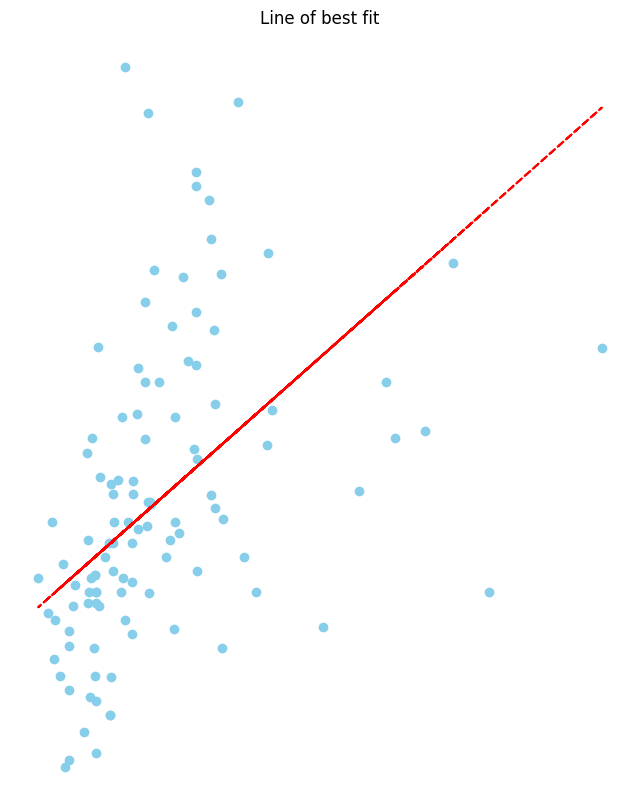

In [413]:
plt.figure(figsize=(8, 10))
plt.scatter(x_test, y_test, color='skyblue', label='Data Points')
plt.plot(x_test, val_preds, color='red', linestyle='--', label='Line of Best Fit on test data')
plt.title("Line of best fit")
plt.axis('off')